<a href="https://colab.research.google.com/github/Hibashanti/Adult-Income-Dataset/blob/main/%D9%90Adult_Income_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult_Income_Dataset

- Author : Hiba Shanti



### Project overview
 -1- Import Libraries and Load the Data



In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder,LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay, recall_score,precision_score, classification_report
from imblearn.pipeline import make_pipeline as make_sampler_pipeline
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE,SMOTENC



In [2]:
# Mount to Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path="/content/drive/MyDrive/Axsos Academy/AXSOSACADEMY-1/05-IntermediateML/Week18/Data/adult.csv"
df=pd.read_csv(path)
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


#### What is the target?
 - Income
#### What does one row represent?
 - individual’s personal information.
#### How many features does the data have
 - 15 features
#### How many rows are in the dataset?
 - 48,841



### Data Exploration / Data Cleaning

In [5]:
# fnlwgt colun represents how many people in the real population this individual represents.
df=df.drop('fnlwgt',axis=1)

In [6]:
# Check for duplications
df.duplicated().sum()

np.int64(6374)

In [7]:
# remove duplications
df.drop_duplicates(inplace=True)
# Confirm
df.duplicated().sum()

np.int64(0)

In [8]:
#check for missing values
df.isna().sum().sum()

np.int64(0)

In [9]:
# Check inconsistances in categorical columns
categorical_col=df.select_dtypes(include='object').columns
for col in categorical_col:
  print(col)
  print(df[col].value_counts())

workclass
workclass
Private             28312
Self-emp-not-inc     3735
Local-gov            3011
?                    2411
State-gov            1927
Self-emp-inc         1644
Federal-gov          1397
Without-pay            21
Never-worked           10
Name: count, dtype: int64
education
education
HS-grad         12919
Some-college     9188
Bachelors        6967
Masters          2499
Assoc-voc        1961
11th             1598
Assoc-acdm       1563
10th             1277
7th-8th           931
Prof-school       813
9th               737
12th              618
Doctorate         576
5th-6th           498
1st-4th           242
Preschool          81
Name: count, dtype: int64
marital-status
marital-status
Married-civ-spouse       19215
Never-married            13360
Divorced                  6218
Separated                 1512
Widowed                   1499
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64
occupation
occupation
Prof-specialty       5679
E

In [10]:
# Replace the "?" value to nan
df.replace('?', np.nan, inplace=True)

In [11]:
# Check inconsistances in numerical value
numerical_col=df.select_dtypes('number').columns
numerical_col

Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [12]:
df.describe()

,age,educational-num,capital-gain,capital-loss,hours-per-week
count,42468.000000,42468.000000,42468.000000,42468.000000,42468.000000
mean,39.476947,10.094801,1226.217128,99.859212,40.650702
std,13.779595,2.658658,7931.500736,429.072095,12.867960
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,29.000000,9.000000,0.000000,0.000000,38.000000
50%,38.000000,10.000000,0.000000,0.000000,40.000000
75%,49.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


### Exploratory Visualizations

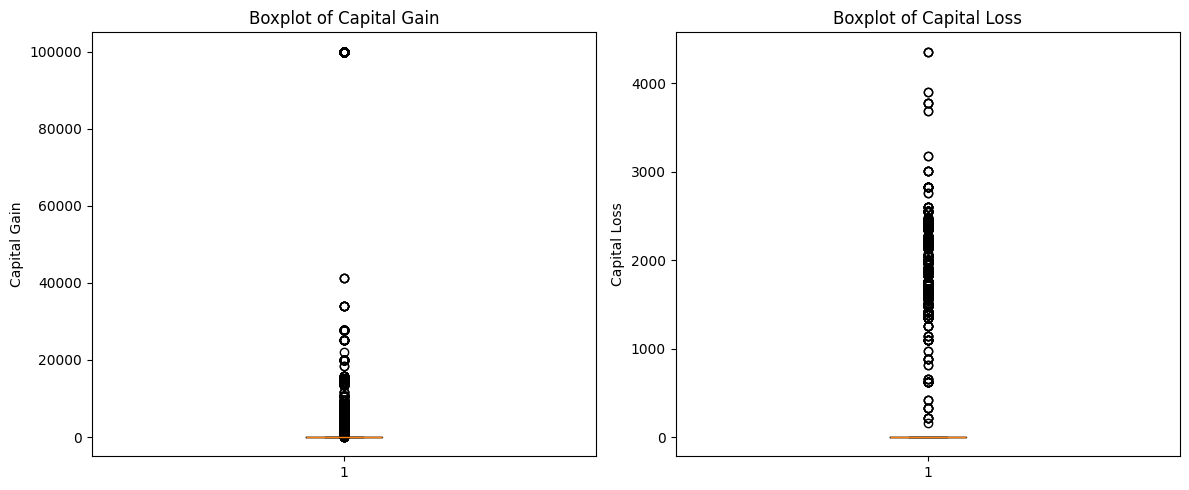

In [13]:
# Visualizing the capital gain and capital loss columns seperatly.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Capital Gain
axes[0].boxplot(df['capital-gain'])
axes[0].set_title('Boxplot of Capital Gain')
axes[0].set_ylabel('Capital Gain')

# Capital Loss
axes[1].boxplot(df['capital-loss'])
axes[1].set_title('Boxplot of Capital Loss')
axes[1].set_ylabel('Capital Loss')

plt.tight_layout()
plt.show()

#Because most values are 0, The boxplot look compressed at the bottom with many extreme outliers.
# This indicates a highly skewed features

In [14]:
def plot_categorical_vs_target(df, x, y, fillna=True, figsize=(6,4),place="MISSING", order=None, target_type="reg" ) :
# make a copy of the df
 df_copy =df.copy()
#fill with placeholder
 if fillna == True :
  df_copy[x]=df_copy[x].fillna(place)
 else :
#drop null
  df_copy=df_copy.dropna(subset=[x])
#plot the graph
 fig,ax=plt.subplots(figsize=figsize)
# REGRESSION-TARGET PLOT
 if target_type == "reg" :
 # stripplot customizing
  sns.stripplot(data=df_copy, x=x, y=y, hue=x, ax=ax,order=order, legend=False, edgecolor="White", linewidth=0.5, size=3, zorder=0)
# Bar plot customizing
  sns.barplot(data=df_copy, x=x, y=y, ax=ax, alpha=0.6, order= order, linewidth=1, edgecolor="black", errorbar=None)
 elif target_type=='class':
  ax = sns.histplot(data=df_copy, hue=y, x=x, stat='percent',  multiple='fill')
 ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
 ax.set_title(f"{x} vs. {y}")
 fig.tight_layout()
 return fig, ax;

/tmp/ipython-input-219/4126389002.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


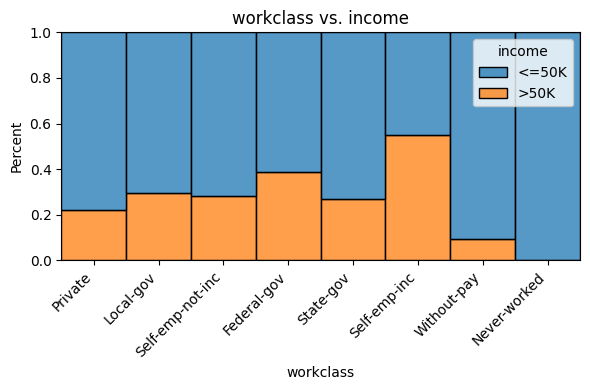

In [15]:
plot_categorical_vs_target(df, x="workclass", y="income", fillna=False, figsize=(6,4),place="MISSING", order=None, target_type="class" );

#Workclass does influence income
#Being Self-emp-inc strongly increases probability of earning >50K
#Most other categories are dominated by ≤50K

### Preprocessing Step


In [16]:
# Split the data
y=df['income']
X=df.drop('income',axis=1)
X_train,X_test, y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
# Chaek the balance
y_train.value_counts(normalize=True)

,proportion
income,
<=50K,0.754665
>50K,0.245335


In [33]:
# Define the tuple for categorical columns
cat_col=X_train.select_dtypes(include='object').columns
#impute missing values
cat_imputer=SimpleImputer(strategy="constant", fill_value="MISSING")
# one hot encoding the data
col_ohe=OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# make pipeline
cat_pipeline=make_pipeline(cat_imputer,col_ohe)
# Make a tuple
cat_tuple=("categorical",cat_pipeline,cat_col)

In [30]:
# Define the tuple for numerical columns
num_col=X_train.select_dtypes(include='number').columns
#impute missing values
num_imputer=SimpleImputer(strategy="median")
# scale
num_scaler=StandardScaler()
# make pipeline
num_pipeline=make_pipeline(num_imputer,num_scaler)
# Make a tuple
num_tuple=("numerical",num_pipeline,num_col)

In [38]:
# Make a column transformer
preprocesser=ColumnTransformer([cat_tuple,num_tuple],remainder="passthrough")
preprocesser.fit_transform(X_train)
preprocesser.transform(X_test)


array([[ 0.        ,  0.        ,  0.        , ..., -0.15424727,
        -0.23352597,  0.72878559],
       [ 0.        ,  0.        ,  0.        , ..., -0.15424727,
        -0.23352597,  0.33951544],
       [ 0.        ,  0.        ,  1.        , ..., -0.15424727,
        -0.23352597, -1.21756518],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.15424727,
        -0.23352597, -0.04975472],
       [ 0.        ,  0.        ,  0.        , ...,  0.22506094,
        -0.23352597,  0.72878559],
       [ 0.        ,  0.        ,  0.        , ..., -0.15424727,
        -0.23352597, -0.82829502]])

In [41]:
# Initaite the model
model=RandomForestClassifier(random_state=42)
#Create a pippeline
model_pipe=make_pipeline(preprocesser,model)
# fit and transform the model on training data
model_pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object')),
                                                 ('numerical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [46]:
def classification_metrics(y_test, y_pred, label='',output_dict=False, figsize=(8,4),normalize='true', cmap='Blues',colorbar=False):
# Get the classification report
 report = classification_report(y_test, y_pred)
 ## Print header and report
 header = "-"*70
 print(header, f" Classification Metrics: {label}", header, sep='\n')
 print(report)
 ## CONFUSION MATRICES SUBPLOTS
 fig, axes = plt.subplots(ncols=2, figsize=figsize)
 # create a confusion matrix  of raw counts
 ConfusionMatrixDisplay.from_predictions(y_test, y_pred,normalize=None, cmap='gist_gray', colorbar=colorbar,ax = axes[0],);
 axes[0].set_title("Raw Counts")
 # create a confusion matrix with the test data
 ConfusionMatrixDisplay.from_predictions(y_test, y_pred,normalize=normalize, cmap=cmap, colorbar=colorbar,ax = axes[1]);
 axes[1].set_title("Normalized Confusion Matrix")
 # Adjust layout and show figure
 fig.tight_layout()
 plt.show()
 # Return dictionary of classification_report
 if output_dict==True:
   report_dict = classification_report(y_test, y_pred, output_dict=True)
   return report_dict
def evaluate_classification(model, X_train, y_train, X_test, y_test,figsize=(6,4), normalize='true', output_dict = False,cmap_train='Blues', cmap_test="Reds",colorbar=False):
 # Get predictions for training data
  y_train_pred = model.predict(X_train)
 # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                    output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_train,label='Training Data')
  print()
 # Get predictions for test data
  y_test_pred = model.predict(X_test)
 # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                 output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_test,label='Test Data' )
  if output_dict == True:
   # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,'test': results_test}
    return results_dict

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.99      0.99      0.99     25639
        >50K       0.97      0.96      0.96      8335

    accuracy                           0.98     33974
   macro avg       0.98      0.97      0.97     33974
weighted avg       0.98      0.98      0.98     33974



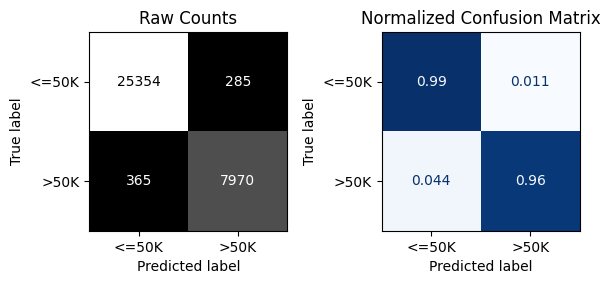


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      6381
        >50K       0.68      0.58      0.63      2113

    accuracy                           0.83      8494
   macro avg       0.77      0.74      0.76      8494
weighted avg       0.82      0.83      0.82      8494



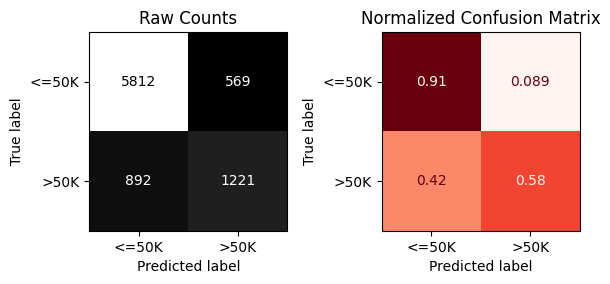

In [47]:
# Evaluate the Model
evaluate_classification(model_pipe, X_train, y_train, X_test, y_test,figsize=(6,8))

In [49]:
#Extract and visualize the top 10 features using permutation importance
from sklearn.inspection import permutation_importance
r = permutation_importance(model_pipe, X_test, y_test,n_repeats =5, random_state = 42)
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

In [52]:
## can make the mean importances into a series
permutation_importances = pd.Series(r['importances_mean'],index=X_test.columns,
                           name = 'permutation importance')
permutation_importances = permutation_importances.sort_values(ascending=False)
permutation_importances.head(10)

,permutation importance
capital-gain,0.043513
capital-loss,0.008665
marital-status,0.008406
educational-num,0.002284
native-country,-0.000235
relationship,-0.001483
workclass,-0.002284
gender,-0.002519
race,-0.002896
occupation,-0.005628


In [61]:
def plot_importance_color_ax(importances, top_n=None,  figsize=(8,6), color_dict=None, ax=None):
# sorting with asc=false for correct order of bars
   if top_n==None:
       ## sort all features and set title
       plot_vals = importances.sort_values()
       title = "All Features - Ranked by Importance"
   else:
       ## sort features and keep top_n and set title
       plot_vals = importances.sort_values().tail(top_n)
       title = f"Top {top_n} Most Important Features"
   ## create plot with colors, if provided
   if color_dict is not None:
       ## Getting color list and saving to plot_kws
       colors = plot_vals.index.map(color_dict)
       ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors, ax=ax)
   else:
## create plot without colors, if not provided
       ax = plot_vals.plot(kind='barh', figsize=figsize, ax=ax)
# set titles and axis labels
   ax.set(xlabel='Importance',ylabel='Feature Names',title=title)
 ## return ax in case want to continue to update/modify figure
   return ax# sorting with asc=false for correct order of bars
   if top_n==None:
       ## sort all features and set title
       plot_vals = importances.sort_values()
       title = "All Features - Ranked by Importance"
   else:
       ## sort features and keep top_n and set title
       plot_vals = importances.sort_values().tail(top_n)
       title = f"Top {top_n} Most Important Features"
   ## create plot with colors, if provided
   if color_dict is not None:
       ## Getting color list and saving to plot_kws
       colors = plot_vals.index.map(color_dict)
       ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors, ax=ax)
   else:
## create plot without colors, if not provided
       ax = plot_vals.plot(kind='barh', figsize=figsize, ax=ax)
# set titles and axis labels
   ax.set(xlabel='Importance',ylabel='Feature Names',title=title)
 ## return ax in case want to continue to update/modify figure
   return ax

<Axes: title={'center': 'Top 10 Most Important Features'}, xlabel='Importance', ylabel='Feature Names'>

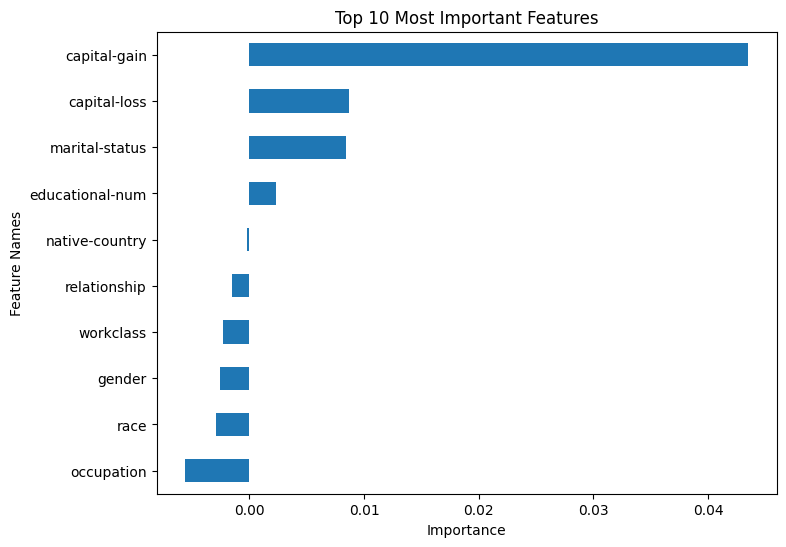

In [64]:
# Visualize top 10 features
plot_importance_color_ax(permutation_importances, top_n=10)


#### Do these features make sense based on the business case?

 -